## Подготовка данных

### Импорты

In [1]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

### Загрузка данных

In [2]:
data = pd.read_csv('processed_data.csv')
data.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,2,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939 entries, 0 to 938
Columns: 195 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(88)
memory usage: 1.4 MB


## Подготовка к обучению данных

In [4]:
df = data.copy()

In [5]:
df['target'] = (df['SI'] > df['SI'].median()).astype(int)

In [6]:
X = df.drop(['IC50, mM', 'SI','target'], axis=1)
y = df['target']

# Разделяем данных на признаки и целевой столбец

### Стандартизация

In [7]:
scales = StandardScaler()
X_scaled = scales.fit_transform(X)

# Проводим стандартизацию признаков

### Понижение размерности

#### PCA

In [8]:
# pca = PCA(n_components=0.90)
# X_pca = pca.fit_transform(X_scaled)

# PCA не подходит, т.к. это линейный метод понижения размерности,
# а по эксперентам далее, я понял, что данные нелинейно заввисимы, поэтому это ухудшает качество модели

#### SelectBest

In [9]:
# Отбор 50 лучших признаков по mutual_info
selector = SelectKBest(score_func=mutual_info_regression, k=50)
X_selected = selector.fit_transform(X_scaled, y)
selected_feature_names = X.columns[selector.get_support()]

### Разделение данных для обучения

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Разделяем данные на обучающую и тестовую выборки

### Подбор гиперпараметров для модели

In [ ]:
models = {
    "LogisticRegression": (
        LogisticRegression(max_iter=5000),
        {
            "C": [0.01, 0.1, 1.0, 10.0]
        }
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, 15],
            "min_samples_split": [2, 5]
        }
    ),
    "XGBoost": (
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [3, 6, 10],
            "learning_rate": [0.01, 0.1, 0.3],
            "subsample": [0.8, 1.0]
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7, 11],
            "weights": ["uniform", "distance"]
        }
    )
}

# Возьмем четыре модели, логистическую регрессию, randomForest, XGBoost и KNN, а также выберем им гиперпараметры

In [ ]:
%%time

results = []

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    })


results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:13:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


CPU times: user 2.75 s, sys: 206 ms, total: 2.95 s
Wall time: 1min 33s


,Model,Best Params,Accuracy,ROC AUC
0,LogisticRegression,{'C': 10.0},0.904255,0.979739
1,RandomForest,"{'max_depth': 15, 'min_samples_split': 5, 'n_e...",0.840426,0.924565
2,XGBoost,"{'learning_rate': 0.3, 'max_depth': 6, 'n_esti...",0.962766,0.995421
3,KNN,"{'n_neighbors': 7, 'weights': 'distance'}",0.675532,0.756525


## Обучение моделей ML

### Логистическая регрессия

In [11]:
# Создаем модель линейной регрессии
log_reg = LogisticRegression(max_iter=5000, C=1)

log_reg.fit(X_train, y_train)

y_log_reg_pred = log_reg.predict(X_test)

# Предсказание классов и вероятностей
y_log_reg_proba = log_reg.predict_proba(X_test)[:, 1]

# Метрики
print("Accuracy:", accuracy_score(y_test, y_log_reg_pred))
print("Precision:", precision_score(y_test, y_log_reg_pred))
print("Recall:", recall_score(y_test, y_log_reg_pred))
print("F1-score:", f1_score(y_test, y_log_reg_pred))
print("ROC AUC:", roc_auc_score(y_test, y_log_reg_proba))
print("\nПолный отчёт для Логистической модели:\n", classification_report(y_test, y_log_reg_pred))

Accuracy: 0.6595744680851063
Precision: 0.6111111111111112
Recall: 0.6547619047619048
F1-score: 0.632183908045977
ROC AUC: 0.6970009157509157

Полный отчёт для Логистической модели:
               precision    recall  f1-score   support

           0       0.70      0.66      0.68       104
           1       0.61      0.65      0.63        84

    accuracy                           0.66       188
   macro avg       0.66      0.66      0.66       188
weighted avg       0.66      0.66      0.66       188



### RandomForest

In [12]:
# Создаем модель линейной регрессии
rf = RandomForestClassifier(max_depth=15,min_samples_split=5,n_estimators=200,random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Предсказание классов и вероятностей
rf_proba = rf.predict_proba(X_test)[:, 1]

# Метрики
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_proba))
print("\nПолный отчёт для Random Forest Classifier:\n", classification_report(y_test, rf_pred))

Accuracy: 0.6595744680851063
Precision: 0.6136363636363636
Recall: 0.6428571428571429
F1-score: 0.627906976744186
ROC AUC: 0.7472527472527473

Полный отчёт для Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.70      0.67      0.69       104
           1       0.61      0.64      0.63        84

    accuracy                           0.66       188
   macro avg       0.66      0.66      0.66       188
weighted avg       0.66      0.66      0.66       188



### XGBoost

In [13]:
xgb = XGBClassifier(learning_rate = 0.3, max_depth=6, n_estimators=200, subsample=0.8 , use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb.fit(X_train, y_train)

y_xgb_pred = xgb.predict(X_test)

# Предсказание классов и вероятностей
xgb_proba = xgb.predict_proba(X_test)[:, 1]

# Метрики
print("Accuracy:", accuracy_score(y_test, y_xgb_pred))
print("Precision:", precision_score(y_test, y_xgb_pred))
print("Recall:", recall_score(y_test, y_xgb_pred))
print("F1-score:", f1_score(y_test, y_xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_proba))
print("\nПолный отчёт для XGBoost:\n", classification_report(y_test, y_xgb_pred))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:50:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.6382978723404256
Precision: 0.5833333333333334
Recall: 0.6666666666666666
F1-score: 0.6222222222222222
ROC AUC: 0.7261904761904762

Полный отчёт для XGBoost:
               precision    recall  f1-score   support

           0       0.70      0.62      0.65       104
           1       0.58      0.67      0.62        84

    accuracy                           0.64       188
   macro avg       0.64      0.64      0.64       188
weighted avg       0.65      0.64      0.64       188



### KNN

In [14]:
knn = KNeighborsClassifier(n_neighbors = 7)
knn.fit(X_train, y_train)

y_knn_pred = knn.predict(X_test)

# Предсказание классов и вероятностей
knn_proba = knn.predict_proba(X_test)[:, 1]

# Метрики
print("Accuracy:", accuracy_score(y_test, y_knn_pred))
print("Precision:", precision_score(y_test, y_knn_pred))
print("Recall:", recall_score(y_test, y_knn_pred))
print("F1-score:", f1_score(y_test, y_knn_pred))
print("ROC AUC:", roc_auc_score(y_test, knn_proba))
print("\nПолный отчёт для KNN:\n", classification_report(y_test, y_knn_pred))

Accuracy: 0.648936170212766
Precision: 0.5849056603773585
Recall: 0.7380952380952381
F1-score: 0.6526315789473685
ROC AUC: 0.7163461538461539

Полный отчёт для KNN:
               precision    recall  f1-score   support

           0       0.73      0.58      0.65       104
           1       0.58      0.74      0.65        84

    accuracy                           0.65       188
   macro avg       0.66      0.66      0.65       188
weighted avg       0.67      0.65      0.65       188



## Вывод

- Все модели показывают хороший результат. Даже если взять базовую логистическую регрессию, мы видим уже тут хорошие показатели

- XGBoost можно использовать в качестве основого классификатора, логистическую регрессию как дополнения, и лучшей интерпритации с использованием _coef

Общая рекомендация это - Ансамбль XGBoost + Log_reg

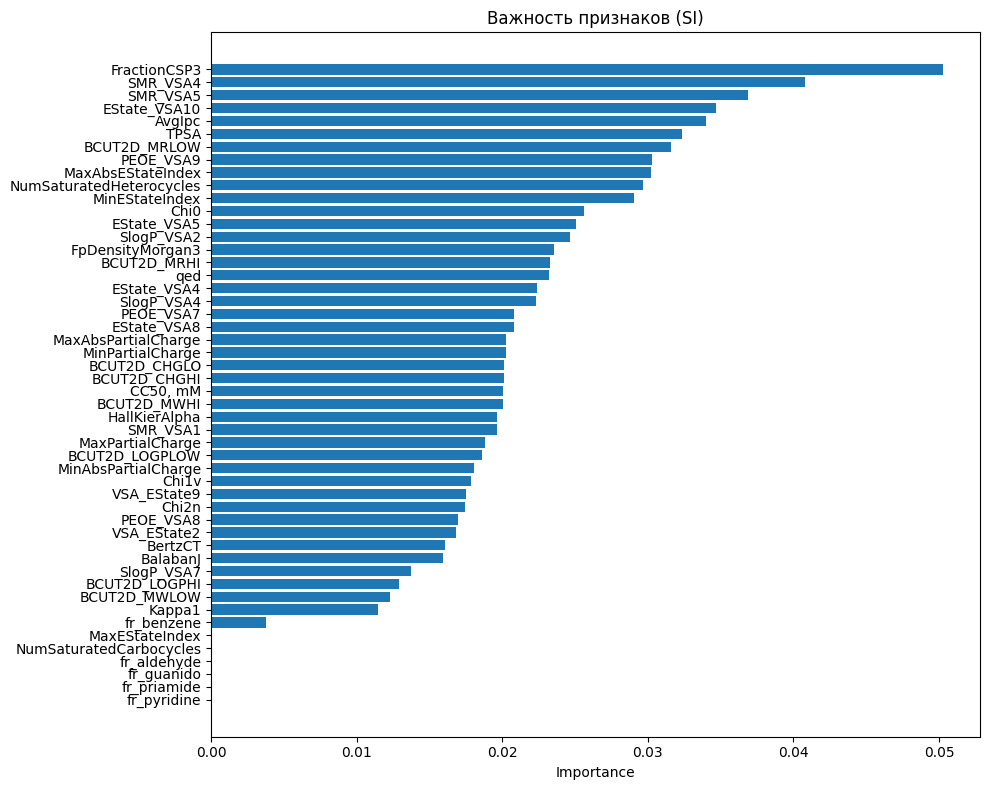

In [15]:
# Построение графика важности признаков
importances = xgb.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': selected_feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Важность признаков (SI)")
plt.tight_layout()
plt.show()